# Egyptian NID digit detection (YOLO)

Trains a 10-class YOLO detector on [`cro4.v1-8.yolov8`](cro4.v1-8.yolov8): one box per Eastern Arabic digit (`٠`–`٩`), classes `0`–`9`.

**Kernel:** select `.venv` before you run anything.

Cursor: `Select Kernel` → `Python Environments` → `.venv` (`Python 3.12`).

If the venv is missing:

```powershell
python -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install -U pip
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
pip install -r requirements.txt
```

This notebook does **not** run card localization. Use [`train_nid_yolo.ipynb`](train_nid_yolo.ipynb) for that. After training here, check **valid exact 14-digit match** before wiring into `yolo+ocr/run_pipeline.py`.

In [ ]:
from pathlib import Path
import sys

ROOT = Path.cwd()
DATASET = ROOT / "cro4.v1-8.yolov8"
if not DATASET.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATASET}")

if ".venv" not in Path(sys.prefix).resolve().parts:
    raise RuntimeError(
        f"This kernel is {sys.executable}\n"
        "Select the project .venv kernel so packages are not installed on system Python."
    )

print("Python:", sys.executable)
print("Project:", ROOT)
print("Dataset:", DATASET)

Python: c:\Users\LOQ\Desktop\I_School\ID-OCR\.venv\Scripts\python.exe
Project: c:\Users\LOQ\Desktop\I_School\ID-OCR
Dataset: c:\Users\LOQ\Desktop\I_School\ID-OCR\cro4.v1-8.yolov8


In [ ]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from ultralytics import YOLO

from tracking.mlflow_setup import configure_mlflow_tracking
from tracking.yolo_mlflow import register_supplemental_mlflow_callbacks

ROOT = Path.cwd()
DATASET = ROOT / "cro4.v1-8.yolov8"
DATA_YAML = ROOT / "nid_digits.yaml"
RUNS_DIR = ROOT / "runs"

EPOCHS = 50
IMGSZ = 640
BATCH = 32
MODEL_NAME = "yolov8n.pt"
LR0 = 0.001
LRF = 0.01
OPTIMIZER = "AdamW"
PATIENCE = 20
CONF = 0.25
DEVICE = 0 if torch.cuda.is_available() else "cpu"

RUN_TRAIN = True
RUN_VAL = True
RUN_EXACT = True

RUN_NAME = configure_mlflow_tracking(
    ROOT,
    experiment_name="nid-digits",
    run_prefix="nid_digits",
)

DIGIT_NAMES = [str(i) for i in range(10)]
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

print("Device:", DEVICE)
print("YOLO run:", RUN_NAME)

Device: 0


## Dataset YAML

[`nid_digits.yaml`](nid_digits.yaml) points at the split `cro4` folder (80/10/10 by unique 14-digit NID). This cell refreshes it if needed.

In [ ]:
fixed = {
    "path": str(DATASET.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 10,
    "names": {i: str(i) for i in range(10)},
}
DATA_YAML.write_text(yaml.safe_dump(fixed, sort_keys=False), encoding="utf-8")
print(DATA_YAML.read_text(encoding="utf-8"))

path: C:\Users\LOQ\Desktop\I_School\ID-OCR\cro4.v1-8.yolov8
train: train/images
val: valid/images
test: test/images
nc: 10
names:
  0: '0'
  1: '1'
  2: '2'
  3: '3'
  4: '4'
  5: '5'
  6: '6'
  7: '7'
  8: '8'
  9: '9'



In [ ]:
def count_split(split: str) -> tuple[int, int, int]:
    images = list((DATASET / split / "images").glob("*.*"))
    labels = list((DATASET / split / "labels").glob("*.txt"))
    boxes = 0
    for path in labels:
        boxes += sum(1 for line in path.read_text(encoding="utf-8").splitlines() if line.strip())
    return len(images), len(labels), boxes


for split in ("train", "valid", "test"):
    n_img, n_lbl, n_box = count_split(split)
    print(f"{split:5}  images={n_img:4}  labels={n_lbl:4}  digit boxes={n_box:5}")

train  images=6795  labels=6795  digit boxes=95130
valid  images= 849  labels= 849  digit boxes=11886
test   images= 850  labels= 850  digit boxes=11900


## Preview labels

Each crop should have **14 boxes**. Class `0` is the dotted zero (`٠`); its box is usually shorter than `2`/`8`.

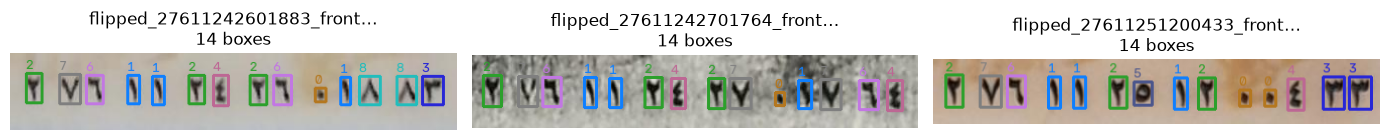

In [ ]:
def resolve_image(stem: str, image_dir: Path) -> Path | None:
    for ext in IMAGE_SUFFIXES:
        path = image_dir / f"{stem}{ext}"
        if path.exists():
            return path
    return None


def load_yolo_boxes(label_path: Path, img_w: int, img_h: int) -> list[tuple[int, int, int, int, int]]:
    boxes: list[tuple[int, int, int, int, int]] = []
    for line in label_path.read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cls_id = int(parts[0])
        xc, yc, bw, bh = map(float, parts[1:5])
        x1 = int((xc - bw / 2) * img_w)
        y1 = int((yc - bh / 2) * img_h)
        x2 = int((xc + bw / 2) * img_w)
        y2 = int((yc + bh / 2) * img_h)
        boxes.append((cls_id, x1, y1, x2, y2))
    boxes.sort(key=lambda item: (item[1] + item[3]) / 2)
    return boxes


def draw_boxes(image: np.ndarray, boxes: list[tuple[int, int, int, int, int]]) -> np.ndarray:
    vis = image.copy()
    palette = plt.cm.tab10(np.linspace(0, 1, 10))
    for cls_id, x1, y1, x2, y2 in boxes:
        color = tuple(int(c * 255) for c in palette[cls_id][:3])
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            vis,
            DIGIT_NAMES[cls_id],
            (x1, max(y1 - 4, 12)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            color,
            1,
            cv2.LINE_AA,
        )
    return vis


preview_labels = sorted((DATASET / "train" / "labels").glob("*.txt"))[:3]
fig, axes = plt.subplots(1, len(preview_labels), figsize=(14, 3))
if len(preview_labels) == 1:
    axes = [axes]

for ax, label_path in zip(axes, preview_labels):
    image_path = resolve_image(label_path.stem, DATASET / "train" / "images")
    if image_path is None:
        ax.set_title(f"missing image: {label_path.stem}")
        ax.axis("off")
        continue
    image = cv2.imread(str(image_path))
    h, w = image.shape[:2]
    boxes = load_yolo_boxes(label_path, w, h)
    vis = cv2.cvtColor(draw_boxes(image, boxes), cv2.COLOR_BGR2RGB)
    ax.imshow(vis)
    ax.set_title(f"{label_path.stem[:28]}…\n{len(boxes)} boxes")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Train

`fliplr=0` — digits are left-to-right; horizontal flip would reverse the number. Cosine LR with AdamW matches the card-localization notebook.

In [ ]:
if RUN_TRAIN:
    model = YOLO(MODEL_NAME)
    register_supplemental_mlflow_callbacks(model)
    results = model.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        project=str(RUNS_DIR),
        name=RUN_NAME,
        exist_ok=False,
        plots=True,
        patience=PATIENCE,
        device=DEVICE,
        workers=0,
        cos_lr=True,
        lr0=LR0,
        lrf=LRF,
        optimizer=OPTIMIZER,
        fliplr=0.0,
        flipud=0.0,
        mixup=0.0,
    )
    print(results.save_dir)
else:
    print("Skipped training (RUN_TRAIN=False)")

Ultralytics 8.4.126  Python-3.12.6 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=c:\Users\LOQ\Desktop\I_School\ID-OCR\nid_digits.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, mult

## Validate (mAP)

Per-class mAP on `valid` and `test`. Useful, but **exact 14-digit string match** (next section) is what matters for NID OCR.

In [ ]:
weights = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
if not weights.exists():
    raise FileNotFoundError(f"No weights at {weights}. Train first or set RUN_TRAIN=True.")

trained = YOLO(str(weights))

if RUN_VAL:
    for split in ("val", "test"):
        metrics = trained.val(data=str(DATA_YAML), imgsz=IMGSZ, split=split)
        print(f"\n{split}  mAP50={float(metrics.box.map50):.4f}  mAP50-95={float(metrics.box.map):.4f}")
        maps = getattr(metrics.box, "maps", None)
        if maps is not None:
            for cls_id, cls_map in enumerate(maps):
                print(f"  class {cls_id}: mAP50-95={float(cls_map):.4f}")
else:
    print("Skipped mAP validation (RUN_VAL=False)")

## Exact 14-digit match

Sort detections left-to-right, join class ids, compare to the 14 digits embedded in each filename. Ground truth comes from the filename, not the label files.

In [ ]:
import re
from dataclasses import dataclass

NID_RE = re.compile(r"(\d{14})")


@dataclass
class ExactMetrics:
    total: int
    exact: int
    has_14_boxes: int
    char_correct: int
    char_total: int

    @property
    def exact_rate(self) -> float:
        return self.exact / self.total if self.total else 0.0

    @property
    def box14_rate(self) -> float:
        return self.has_14_boxes / self.total if self.total else 0.0

    @property
    def char_rate(self) -> float:
        return self.char_correct / self.char_total if self.char_total else 0.0


def gt_nid_from_stem(stem: str) -> str | None:
    match = NID_RE.search(stem)
    return match.group(1) if match else None


def pred_nid_from_result(result, conf: float = CONF) -> tuple[str | None, int]:
    if result.boxes is None or len(result.boxes) == 0:
        return None, 0
    cls = result.boxes.cls.cpu().numpy().astype(int)
    scores = result.boxes.conf.cpu().numpy()
    xyxy = result.boxes.xyxy.cpu().numpy()
    keep = scores >= conf
    if not keep.any():
        return None, 0
    cls = cls[keep]
    xyxy = xyxy[keep]
    order = np.argsort([(box[0] + box[2]) / 2 for box in xyxy])
    digits = "".join(str(int(cls[i])) for i in order)
    return digits, len(digits)


def eval_exact_match(model: YOLO, split: str, conf: float = CONF) -> ExactMetrics:
    image_dir = DATASET / split / "images"
    images = sorted(
        path
        for path in image_dir.iterdir()
        if path.suffix.lower() in IMAGE_SUFFIXES
    )
    exact = 0
    has_14 = 0
    char_correct = 0
    char_total = 0
    misses: list[tuple[str, str | None, str | None]] = []

    results = model.predict(
        source=[str(path) for path in images],
        imgsz=IMGSZ,
        conf=conf,
        stream=True,
        verbose=False,
    )
    for path, result in zip(images, results):
        gt = gt_nid_from_stem(path.stem)
        if gt is None:
            continue
        pred, n_boxes = pred_nid_from_result(result, conf=conf)
        if n_boxes == 14:
            has_14 += 1
        if pred == gt:
            exact += 1
        elif len(misses) < 8:
            misses.append((path.name, gt, pred))
        compare = pred or ""
        for i in range(14):
            char_total += 1
            if i < len(compare) and compare[i] == gt[i]:
                char_correct += 1

    metrics = ExactMetrics(
        total=len(images),
        exact=exact,
        has_14_boxes=has_14,
        char_correct=char_correct,
        char_total=char_total,
    )
    print(
        f"{split:5}  exact={metrics.exact}/{metrics.total} ({metrics.exact_rate:.1%})  "
        f"14-box={metrics.has_14_boxes}/{metrics.total} ({metrics.box14_rate:.1%})  "
        f"char={metrics.char_rate:.1%}"
    )
    if misses:
        print("sample misses (filename, gt, pred):")
        for row in misses:
            print(" ", row)
    return metrics


if RUN_EXACT:
    valid_metrics = eval_exact_match(trained, "valid", conf=CONF)
    test_metrics = eval_exact_match(trained, "test", conf=CONF)
else:
    print("Skipped exact match (RUN_EXACT=False)")

## Next

```powershell
python yolo+ocr/digit_nid.py --input yolo+ocr/crops/pred/ID --device 0
python yolo+ocr/run_pipeline.py --source yolo+ocr/real-samples --device 0
```

Weights: `runs/nid_digits/weights/best.pt`. Card localization: [`train_nid_yolo.ipynb`](train_nid_yolo.ipynb).